# 03 — Balance the crop dataset and train the ResNet baseline

This notebook has two connected parts:

1. Build a new class-aware dataset by augmenting only defective object crops.
2. Train and evaluate a leakage-safe class-conditioned ResNet18 baseline.

The original crop folders and segmentation result CSVs are never modified.

## Pipeline position

`Object crops → defect balancing → grouped split → ResNet18 baseline`

## Why source grouping matters

One source image can produce multiple crops, and one defective crop can produce
multiple augmented children. All related records must remain in the same split.
Validation and test metrics use only real, non-augmented crops.


## 1. Locate project modules and import dependencies

The notebook searches common RIDAC locations so it can be launched from either
the experiment folder or a parent repository. The balancing implementation
lives in `balance_defective_dataset.py`.


In [1]:
# Locate the balancing module and import notebook dependencies
from pathlib import Path
import sys

here = Path.cwd().resolve()
candidates = [here, here / "misc" / "ridac"]
candidates.extend(parent / "misc" / "ridac" for parent in here.parents)
MODULE_DIR = next(
    (path for path in dict.fromkeys(candidates) if (path / "balance_defective_dataset.py").is_file()),
    None,
)
if MODULE_DIR is None:
    raise FileNotFoundError("Could not locate misc/ridac/balance_defective_dataset.py")
sys.path.insert(0, str(MODULE_DIR))

import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
from IPython.display import display

from balance_defective_dataset import (
    BalanceConfig,
    create_balanced_dataset,
    load_source_rows,
)


## 2. Configure conservative defective-crop augmentation

The target is a 0.5 defective-to-normal ratio within each product class, with
at most eight generated children per real defective parent. Highly imbalanced
classes may remain below the target; the training sampler handles the remaining
imbalance.

All transforms are intentionally mild to preserve the defect itself.


In [2]:
# Define reproducible augmentation limits and transform ranges
# Every setting is stored in augmentation_config.json for reproducibility.
config = BalanceConfig(
    defective_to_normal_ratio=0.50,
    max_augmentations_per_defective=8,
    rotation_degrees=15.0,
    brightness_change=0.15,
    contrast_change=0.10,
    saturation_change=0.10,
    scale_change=0.05,
    max_noise_sigma=2.0,
    seed=42,
    output_name=None,  # Automatic unique name based on source CSV, ratio, and seed.
)
config


BalanceConfig(ridac_dir=PosixPath('/home/student/Deep-Mtech/misc/ridac'), defective_to_normal_ratio=0.5, max_augmentations_per_defective=8, rotation_degrees=15.0, brightness_change=0.15, contrast_change=0.1, saturation_change=0.1, scale_change=0.05, max_noise_sigma=2.0, seed=42, output_name=None)

## 3. Preview how many defective crops will be generated

This read-only calculation shows, per class:

- Current normal and defective counts.
- The requested defective target.
- The per-parent safety cap.
- The actual number of new crops that can be generated.

Review this table before writing a large derived dataset.


In [3]:
# Calculate class-wise augmentation requirements before writing files
source_table, source_tag = load_source_rows(config)
# Compare current labels independently for every product category.
current_counts = pd.crosstab(
    source_table["source_class"], source_table["assigned_label"]
).reindex(columns=["normal", "defective"], fill_value=0)
current_counts["requested_defective_target"] = (
    current_counts["normal"] * config.defective_to_normal_ratio
).apply(lambda value: int(-(-value // 1)))
current_counts["requested_augmentation"] = (
    current_counts["requested_defective_target"] - current_counts["defective"]
).clip(lower=0)
current_counts["safe_augmentation_cap"] = (
    current_counts["defective"] * config.max_augmentations_per_defective
)
current_counts["defective_to_generate"] = current_counts[[
    "requested_augmentation", "safe_augmentation_cap"
]].min(axis=1)
display(current_counts)
print("Total new defective crops:", int(current_counts["defective_to_generate"].sum()))


Loaded 34,111 valid crops from full_results.csv


assigned_label,normal,defective,requested_defective_target,requested_augmentation,safe_augmentation_cap,defective_to_generate
source_class,,,,,,
candle,4292,108,2146,2038,864,864
capsules,13978,110,6989,6879,880,880
cashew,500,100,250,150,800,150
chewinggum,504,99,252,153,792,153
fryum,500,100,250,150,800,150
macaroni1,4295,105,2148,2043,840,840
macaroni2,4301,101,2151,2050,808,808
pcb1,1008,96,504,408,768,408
pcb2,1001,100,501,401,800,401


Total new defective crops: 5608


## 4. Materialize the balanced dataset

Original crops are hard-linked when the filesystem supports it and copied as a
fallback. Only generated defective children consume new image storage.

Completed outputs are reused rather than overwritten, making the operation
safe to resume.


In [4]:
# Create or reuse the balanced dataset and its audit reports
balanced_manifest, balance_report, balanced_root = create_balanced_dataset(config)
display(balance_report)
print("Balanced dataset:", balanced_root)
print("Manifest:", balanced_root / "balanced_manifest.csv")


Loaded 34,111 valid crops from full_results.csv
Balanced dataset already exists; nothing was overwritten: /home/student/Deep-Mtech/misc/ridac/object_defect_dataset/balanced_augmented_full_r50_cap8_seed42


,source_class,normal_original,defective_original,requested_defective_target,maximum_generated_from_cap,defective_augmented,defective_final,target_shortfall_after_cap,final_defective_to_normal_ratio
0,candle,4292,108,2146,864,864,972,1174,0.226468
1,capsules,13978,110,6989,880,880,990,5999,0.070826
2,cashew,500,100,250,800,150,250,0,0.500000
3,chewinggum,504,99,252,792,153,252,0,0.500000
4,fryum,500,100,250,800,150,250,0,0.500000
5,macaroni1,4295,105,2148,840,840,945,1203,0.220023
6,macaroni2,4301,101,2151,808,808,909,1242,0.211346
7,pcb1,1008,96,504,768,408,504,0,0.500000
8,pcb2,1001,100,501,800,401,501,0,0.500500
9,pcb3,1006,100,503,800,403,503,0,0.500000


Balanced dataset: /home/student/Deep-Mtech/misc/ridac/object_defect_dataset/balanced_augmented_full_r50_cap8_seed42
Manifest: /home/student/Deep-Mtech/misc/ridac/object_defect_dataset/balanced_augmented_full_r50_cap8_seed42/balanced_manifest.csv


## 5. Verify the resulting label and augmentation counts

The cross-tab separates original and augmented records for each class. Confirm
that:

- No normal images were synthetically generated.
- Augmented rows appear only under `defective`.
- The total matches the manifest written by the previous cell.


In [5]:
# Summarize original and augmented records by class and label
final_counts = pd.crosstab(
    [balanced_manifest["source_class"]],
    [balanced_manifest["assigned_label"], balanced_manifest["is_augmented"]],
)
display(final_counts)
print("Total rows:", len(balanced_manifest))
print("New augmented rows:", int(balanced_manifest["is_augmented"].sum()))


assigned_label defective       normal
is_augmented       False True   False
source_class                         
candle               108   864   4292
capsules             110   880  13978
cashew               100   150    500
chewinggum            99   153    504
fryum                100   150    500
macaroni1            105   840   4295
macaroni2            101   808   4301
pcb1                  96   408   1008
pcb2                 100   401   1001
pcb3                 100   403   1006
pcb4                 100   403   1005
pipe_fryum           102   148    500

Total rows: 39719
New augmented rows: 5608


## 6. Visually inspect parent/child augmentation pairs

The left column shows a real defective crop and the right column its generated
child. Look for label-destroying transformations, excessive black borders,
severe color shifts, or defects that have become invisible.


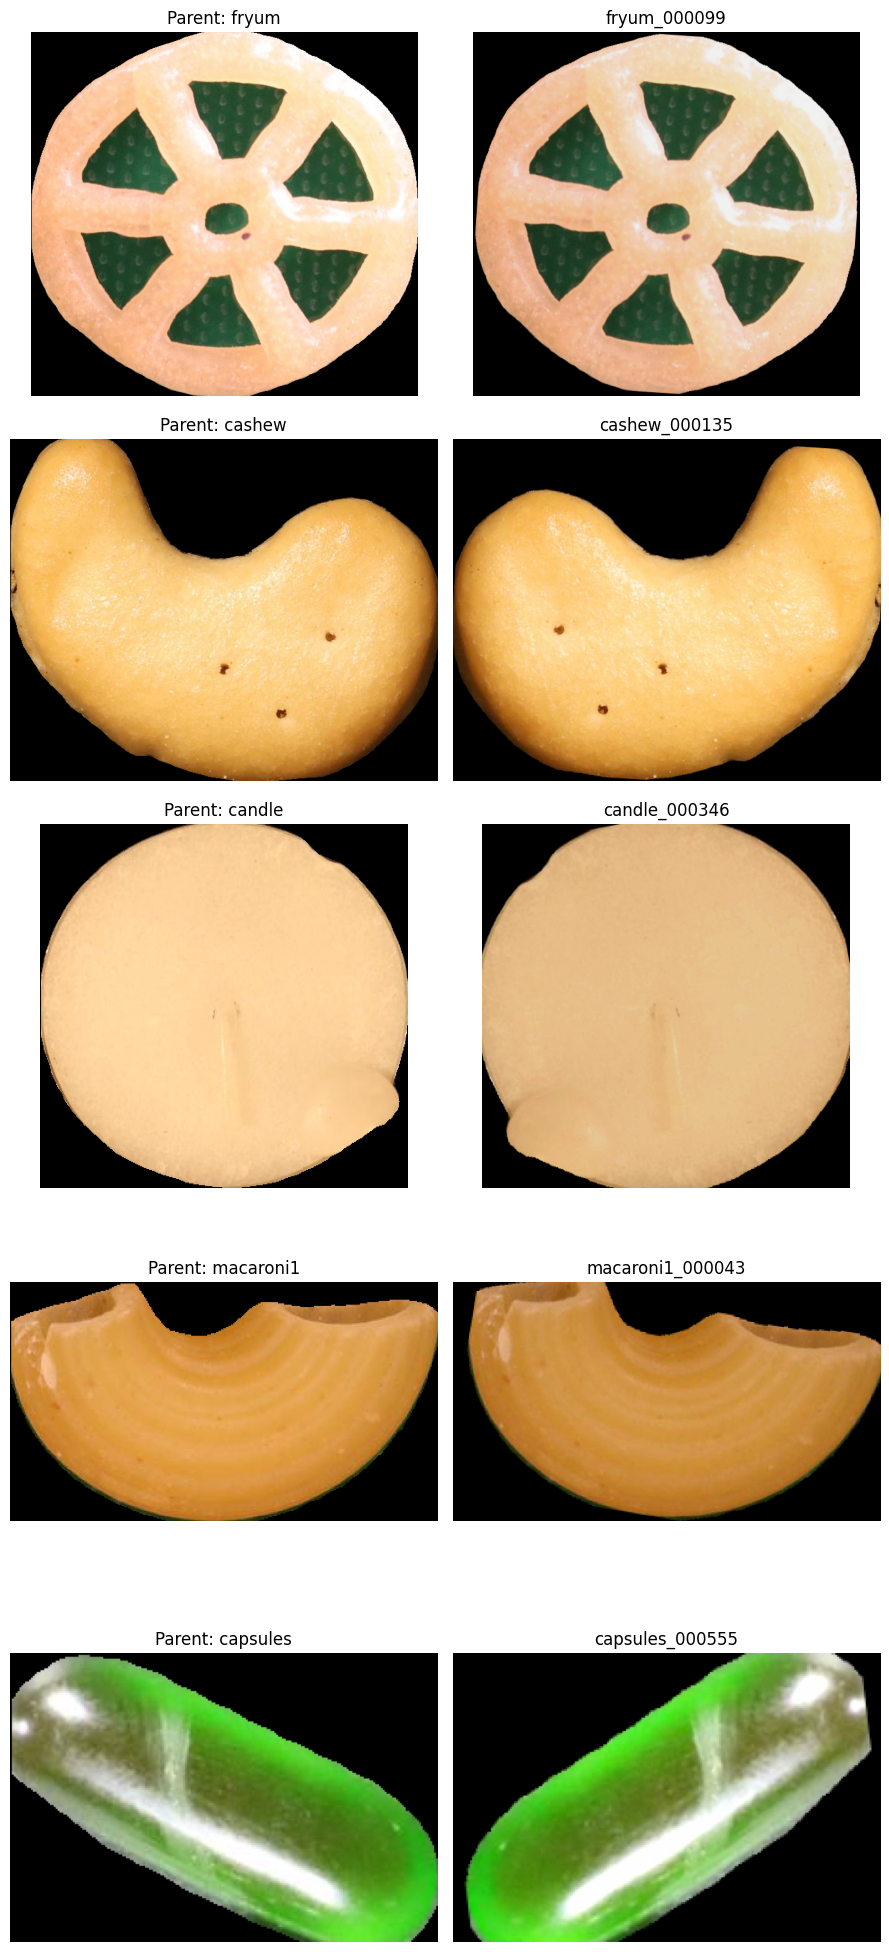

In [6]:
# Display reproducible defective-parent and augmented-child examples
# A fixed random state keeps documentation screenshots reproducible.
examples = (
    balanced_manifest.loc[balanced_manifest["is_augmented"].eq(True)]
    .sample(n=min(5, int(balanced_manifest["is_augmented"].sum())), random_state=42)
)
if examples.empty:
    print("No augmentation was necessary; the source data was already balanced.")
else:
    figure, axes = plt.subplots(len(examples), 2, figsize=(9, 4 * len(examples)), squeeze=False)
    for row_index, (_, row) in enumerate(examples.iterrows()):
        with Image.open(row["parent_crop_path"]) as parent:
            axes[row_index, 0].imshow(parent.convert("RGB"))
        with Image.open(row["crop_path"]) as child:
            axes[row_index, 1].imshow(child.convert("RGB"))
        axes[row_index, 0].set_title(f"Parent: {row['source_class']}")
        axes[row_index, 1].set_title(row["augmentation_id"])
        axes[row_index, 0].axis("off")
        axes[row_index, 1].axis("off")
    figure.tight_layout()
    plt.show()


# Part B — Train the class-conditioned ResNet18 baseline

The model receives both the masked RGB crop and its known product class. The
class embedding drives spatial attention and FiLM feature modulation before a
single binary head predicts `P(defective)`.

This baseline establishes a fair split and evaluation protocol reused by
MobileNetV3 and EfficientNet-B0 in notebook 05.


## 7. Configure training and output artifacts

The baseline uses ImageNet-pretrained ResNet18, 224 × 224 inputs, class/label
balanced sampling, mixed precision on CUDA, cosine learning-rate decay,
gradient clipping, and early stopping on validation PR-AUC.


In [7]:
# Import training utilities and define the ResNet18 experiment
from dataclasses import asdict
import json
import numpy as np
import torch

from conditional_resnet import (
    Config as TrainingConfig,
    best_f1_threshold,
    build_loaders,
    build_model,
    make_grouped_splits,
    predict_image,
    predict_loader,
    save_reports,
    seed_everything as seed_training,
    train_model,
)

# This configuration is serialized into the final checkpoint.
training_config = TrainingConfig(
    ridac_dir=config.ridac_dir,
    output_dir_name=f"{balanced_root.name}/resnet_training_results",
    backbone="resnet18",
    pretrained=True,
    image_size=224,
    batch_size=128,
    epochs=20,
    early_stopping_patience=5,
    learning_rate=3e-4,
    backbone_lr_multiplier=0.20,
    weight_decay=1e-4,
    dropout=0.30,
    embedding_dim=128,
    label_smoothing=0.02,
    seed=42,
    compile_model=False,
)
TRAINING_OUTPUT = balanced_root / "resnet_training_results"
TRAINING_OUTPUT.mkdir(parents=True, exist_ok=True)
training_config


Config(ridac_dir=PosixPath('/home/student/Deep-Mtech/misc/ridac'), output_dir_name='balanced_augmented_full_r50_cap8_seed42/resnet_training_results', backbone='resnet18', pretrained=True, image_size=224, batch_size=128, epochs=20, early_stopping_patience=5, learning_rate=0.0003, backbone_lr_multiplier=0.2, weight_decay=0.0001, dropout=0.3, embedding_dim=128, label_smoothing=0.02, num_workers=8, seed=42, test_folds=5, val_folds=5, compile_model=False)

## 8. Create a leakage-safe grouped split

The split is created from real rows only. Each augmented child then inherits
the split assigned to its real parent source image. Augmented rows outside the
training split are excluded.

The assertions are deliberate safeguards: do not remove them. They prove that
source-image groups cannot cross from training into validation or test.


In [8]:
# Build grouped train/validation/test partitions and enforce no leakage
seed_training(training_config.seed)
training_table = balanced_manifest.copy()
training_table["is_augmented"] = training_table["is_augmented"].astype(str).str.lower().eq("true")
class_names = sorted(training_table["source_class"].unique())
class_to_idx = {name: index for index, name in enumerate(class_names)}
training_table["class_id"] = training_table["source_class"].map(class_to_idx)
training_table["target"] = training_table["assigned_label"].map({"normal": 0, "defective": 1})
training_table["stratum"] = (
    training_table["source_class"] + "__" + training_table["assigned_label"]
)

# Define split boundaries using real data only.
real_rows = training_table.loc[~training_table["is_augmented"]].copy()
real_split = make_grouped_splits(real_rows, training_config)
group_to_split = (
    real_split[["source_image", "split"]]
    .drop_duplicates("source_image")
    .set_index("source_image")["split"]
)
training_table["split"] = training_table["source_image"].map(group_to_split)
if training_table["split"].isna().any():
    raise RuntimeError("Some augmented rows could not be matched to their real parent group.")

# Keep all real rows, but augmented rows only when their parent group is training.
# Keep synthetic rows only when their parent belongs to training.
model_table = training_table.loc[
    (~training_table["is_augmented"]) | training_table["split"].eq("train")
].copy()
assert not model_table.loc[model_table["split"].isin(["val", "test"]), "is_augmented"].any()
assert set(model_table.loc[model_table["split"].eq("val"), "source_image"]).isdisjoint(
    set(model_table.loc[model_table["split"].eq("train"), "source_image"])
)
assert set(model_table.loc[model_table["split"].eq("test"), "source_image"]).isdisjoint(
    set(model_table.loc[model_table["split"].eq("train"), "source_image"])
)
model_table.to_csv(TRAINING_OUTPUT / "balanced_training_split_manifest.csv", index=False)

split_summary = model_table.groupby(
    ["split", "source_class", "assigned_label", "is_augmented"]
).size().rename("rows").reset_index()
display(split_summary)
print("Model rows by split:", model_table.groupby("split").size().to_dict())
print(
    "Augmented rows used for training:",
    int(model_table.loc[model_table["split"].eq("train"), "is_augmented"].sum()),
)
print("Validation/test augmented rows:", int(
    model_table.loc[model_table["split"].isin(["val", "test"]), "is_augmented"].sum()
))


,split,source_class,assigned_label,is_augmented,rows
0,test,candle,defective,False,21
1,test,candle,normal,False,859
2,test,capsules,defective,False,22
3,test,capsules,normal,False,2788
4,test,cashew,defective,False,20
...,...,...,...,...,...
79,val,pcb3,normal,False,161
80,val,pcb4,defective,False,16
81,val,pcb4,normal,False,160
82,val,pipe_fryum,defective,False,16


Model rows by split: {'test': 6815, 'train': 25439, 'val': 5467}
Augmented rows used for training: 3610
Validation/test augmented rows: 0


## 9. Build data loaders and train

The loader sampler balances each `(product class, binary label)` group so
common normal categories do not dominate optimization.

Training can be lengthy. The history is saved after completion and the best
validation state is restored by the training helper.


In [9]:
# Construct loaders, initialize ResNet18, and optimize the baseline
loaders, datasets, eval_transform = build_loaders(model_table, training_config)
# Automatically use CUDA when available; CPU remains a slow fallback.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = build_model(training_config, len(class_to_idx), device)
trainable_parameters = sum(
    parameter.numel() for parameter in model.parameters() if parameter.requires_grad
)
print(f"Device: {device}; trainable parameters: {trainable_parameters:,}")
print(
    "Train/validation/test batches:",
    {name: len(loader) for name, loader in loaders.items()},
)

model, history, best_validation_pr_auc = train_model(
    model, loaders, training_config, device
)
history.to_csv(TRAINING_OUTPUT / "training_history.csv", index=False)


Device: cuda; trainable parameters: 11,640,898
Train/validation/test batches: {'train': 199, 'val': 43, 'test': 54}


train:   0%|          | 0/199 [00:00<?, ?it/s]

eval:   0%|          | 0/43 [00:00<?, ?it/s]

Epoch 01/20: loss=0.2367/0.0600, PR-AUC=0.9777/0.7922


train:   0%|          | 0/199 [00:00<?, ?it/s]

...

eval:   0%|          | 0/43 [00:00<?, ?it/s]

Epoch 17/20: loss=0.0594/0.0367, PR-AUC=0.9999/0.9272


train:   0%|          | 0/199 [00:00<?, ?it/s]

eval:   0%|          | 0/43 [00:00<?, ?it/s]

Epoch 18/20: loss=0.0593/0.0370, PR-AUC=1.0000/0.9251
Early stopping after epoch 18; best validation PR-AUC=0.9340


## 10. Select the decision threshold on validation data

The validation set chooses the threshold that maximizes F1. The test set is
then evaluated once with that fixed threshold. This avoids tuning directly on
test labels.

Saved artifacts include validation/test predictions, overall metrics,
per-class metrics, training curves, evaluation plots, class mappings, and the
best checkpoint.


predict:   0%|          | 0/43 [00:00<?, ?it/s]

Validation-selected threshold: 0.309326


predict:   0%|          | 0/54 [00:00<?, ?it/s]

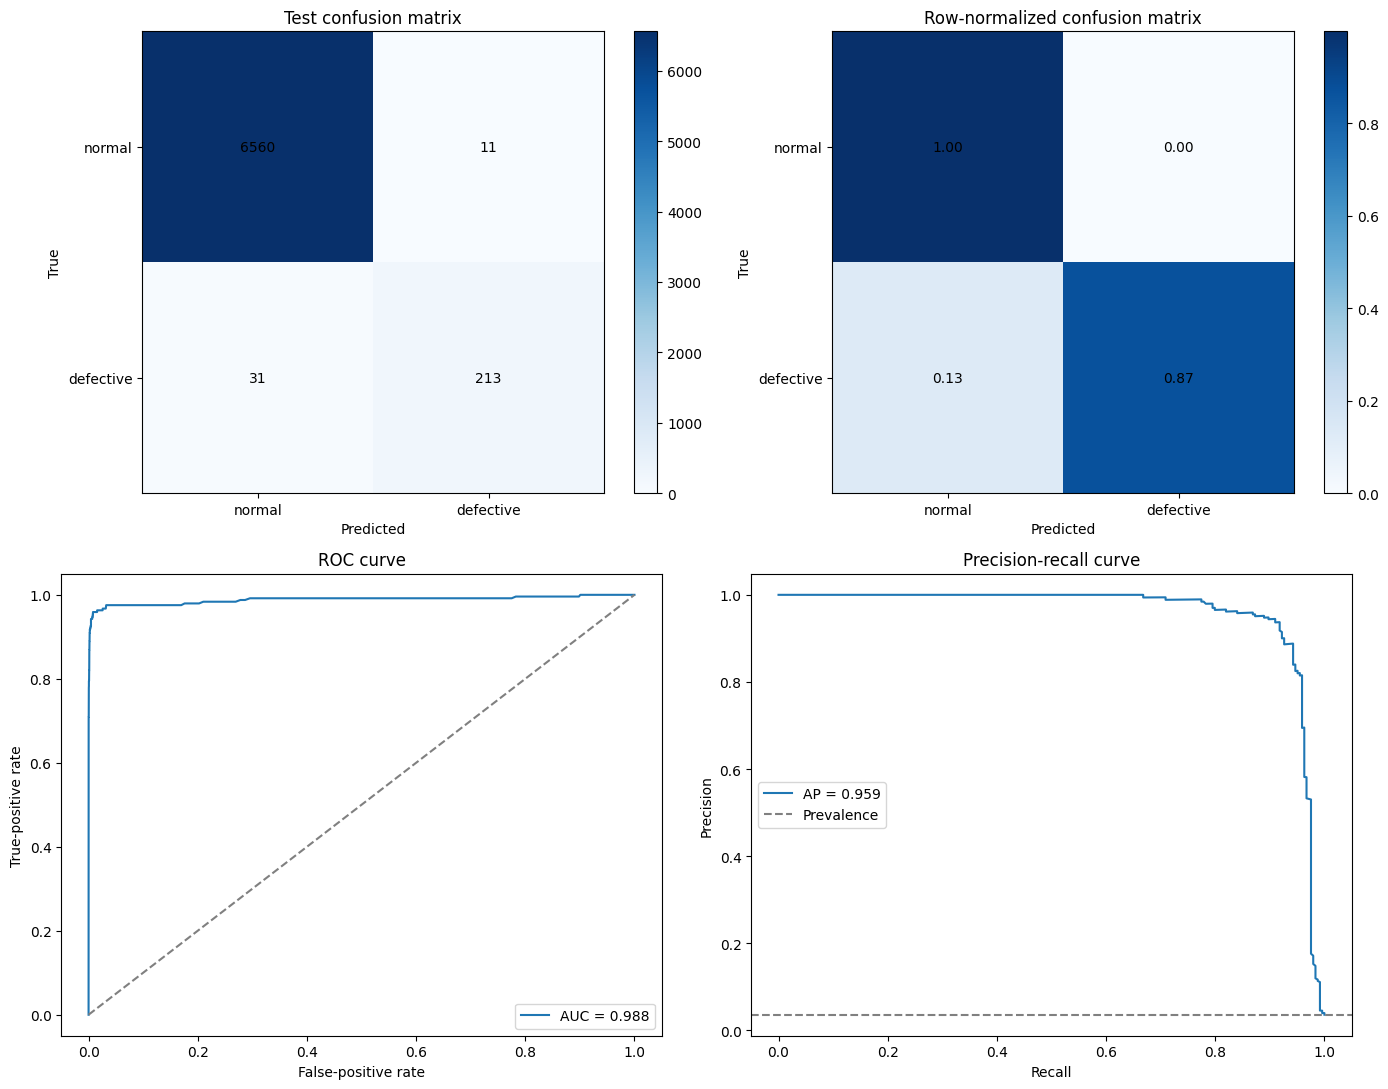

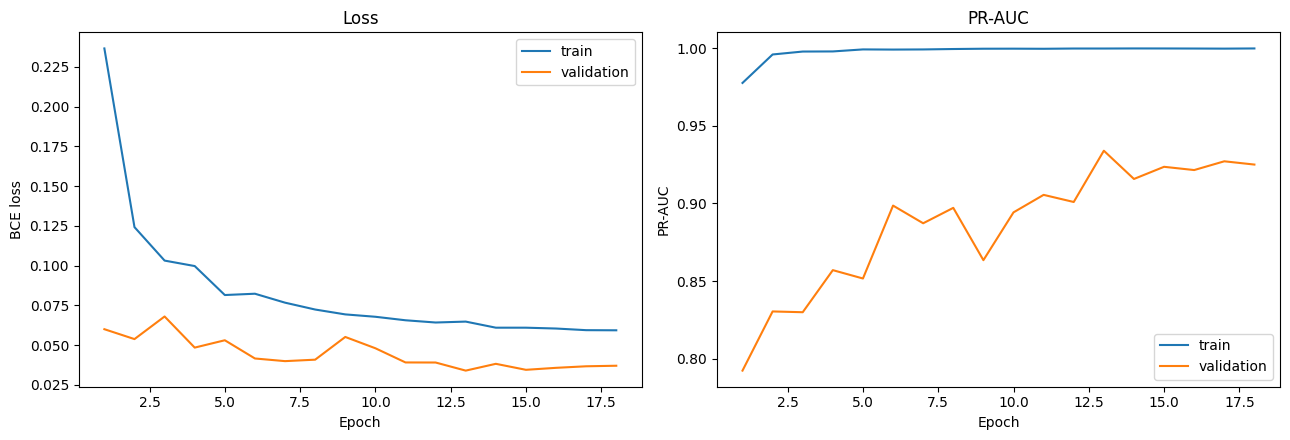

Checkpoint and reports saved to: /home/student/Deep-Mtech/misc/ridac/object_defect_dataset/balanced_augmented_full_r50_cap8_seed42/resnet_training_results


In [10]:
# Tune the threshold, evaluate the held-out test set, and save artifacts
validation_predictions = predict_loader(model, loaders["val"], device)
# Threshold selection uses validation labels only.
threshold = best_f1_threshold(
    validation_predictions["target"].to_numpy(),
    validation_predictions["probability_defective"].to_numpy(),
)
validation_predictions.to_csv(TRAINING_OUTPUT / "validation_predictions.csv", index=False)
print(f"Validation-selected threshold: {threshold:.6f}")

# The untouched test set is evaluated once after threshold selection.
test_predictions = predict_loader(model, loaders["test"], device)
overall_metrics, per_class_metrics = save_reports(
    test_predictions,
    history,
    threshold,
    TRAINING_OUTPUT,
)

checkpoint = {
    "model_state_dict": model.state_dict(),
    "class_to_idx": class_to_idx,
    "threshold": threshold,
    "config": {
        key: str(value) if isinstance(value, Path) else value
        for key, value in asdict(training_config).items()
    },
    "best_validation_pr_auc": best_validation_pr_auc,
    "balanced_manifest": str((balanced_root / "balanced_manifest.csv").resolve()),
}
torch.save(checkpoint, TRAINING_OUTPUT / "best_conditional_resnet.pt")
with (TRAINING_OUTPUT / "class_to_idx.json").open("w", encoding="utf-8") as handle:
    json.dump(class_to_idx, handle, indent=2)
print("Checkpoint and reports saved to:", TRAINING_OUTPUT)


## 11. Review overall, per-class, and macro metrics

Overall accuracy can look excellent in an imbalanced problem, so also inspect:

- Defective recall/sensitivity.
- F1 and Matthews correlation coefficient.
- PR-AUC.
- Per-class confusion counts.
- Macro averages across product classes.


In [11]:
# Display the saved evaluation views used for model comparison
display(overall_metrics.T.rename(columns={"overall": "value"}))
display(per_class_metrics[[
    "samples", "accuracy", "balanced_accuracy", "precision",
    "recall_sensitivity", "specificity", "negative_predictive_value",
    "f1", "mcc", "roc_auc", "pr_auc", "brier_score",
    "tn", "fp", "fn", "tp",
]])
macro_metrics = per_class_metrics[[
    "accuracy", "balanced_accuracy", "precision", "recall_sensitivity",
    "specificity", "f1", "mcc", "roc_auc", "pr_auc", "brier_score",
]].mean().rename("macro_average_across_classes")
display(macro_metrics.to_frame())


,value
samples,6815.000000
threshold,0.309326
accuracy,0.993837
balanced_accuracy,0.935638
precision,0.950893
recall_sensitivity,0.872951
specificity,0.998326
negative_predictive_value,0.995297
f1,0.910256
mcc,0.907961


,samples,accuracy,balanced_accuracy,precision,recall_sensitivity,specificity,negative_predictive_value,f1,mcc,roc_auc,pr_auc,brier_score,tn,fp,fn,tp
source_class,,,,,,,,,,,,,,,,
candle,880,0.994318,0.904180,0.944444,0.809524,0.998836,0.995360,0.871795,0.871608,0.973918,0.900000,0.005423,858,1,4,17
capsules,2810,0.997509,0.908553,0.857143,0.818182,0.998924,0.998566,0.837209,0.836184,0.999511,0.931895,0.002231,2785,3,4,18
cashew,120,0.991667,0.995000,0.952381,1.000000,0.990000,1.000000,0.975610,0.971008,0.999500,0.997619,0.010105,99,1,0,20
chewinggum,121,0.991736,0.975000,1.000000,0.950000,1.000000,0.990196,0.974359,0.969890,0.975743,0.964493,0.008205,101,0,1,19
fryum,120,0.975000,0.945000,0.947368,0.900000,0.990000,0.980198,0.923077,0.908589,0.997500,0.986769,0.022697,99,1,2,18
macaroni1,880,0.998864,0.999418,0.954545,1.000000,0.998836,1.000000,0.976744,0.976440,1.000000,1.000000,0.000273,858,1,0,21
macaroni2,880,0.994318,0.875000,1.000000,0.750000,1.000000,0.994220,0.857143,0.863519,0.971657,0.937353,0.005272,860,0,5,15
pcb1,221,0.972851,0.889786,0.882353,0.789474,0.990099,0.980392,0.833333,0.820105,0.985149,0.939878,0.018229,200,2,4,15
pcb2,220,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.001862,200,0,0,20


,macro_average_across_classes
accuracy,0.987808
balanced_accuracy,0.934121
precision,0.950787
recall_sensitivity,0.872265
specificity,0.995977
f1,0.905074
mcc,0.901957
roc_auc,0.987116
pr_auc,0.953123
brier_score,0.010761


## 12. Inspect class-conditioned attention on a real test crop

This qualitative check helps confirm that the model attends to the object rather
than black padding or irrelevant background. The product class passed to
`predict_image` must match the crop.


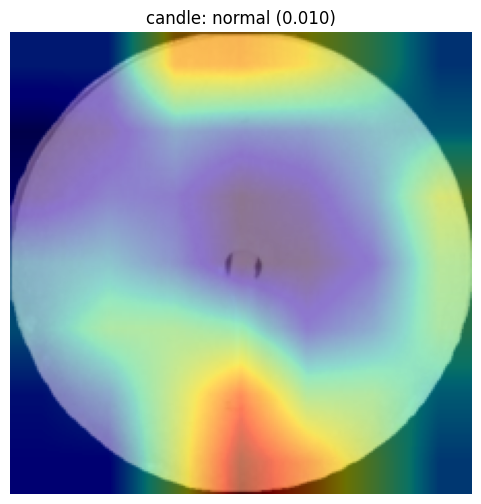

{'class_name': 'candle',
 'predicted_label': 'normal',
 'probability_defective': 0.010052207857370377,
 'threshold': 0.309326171875}

In [12]:
# Visualize attention and predict one held-out object crop
example = test_predictions.iloc[0]
prediction = predict_image(
    model=model,
    image_path=example["crop_path"],
    class_name=example["source_class"],
    class_to_idx=class_to_idx,
    transform=eval_transform,
    device=device,
    threshold=threshold,
    show_attention=True,
)
prediction


## 13. Handoff to lightweight model comparison

Notebook `05_train_mobilenet_efficientnet.ipynb` reuses this exact split
manifest to compare ResNet18 fairly against MobileNetV3-Large and
EfficientNet-B0.
